In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sklearn as sk
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

file_path = "../data/data.csv"
df = pd.read_csv(file_path)
df.head(10)

,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,fail
0,0,7,7,1,6,6,36,3,1,1
1,190,1,3,3,5,1,20,4,1,0
2,31,7,2,2,6,1,24,6,1,0
3,83,4,3,4,5,1,28,6,1,0
4,640,7,5,6,4,0,68,6,1,0
5,110,3,3,4,6,1,21,4,1,0
6,100,7,5,6,4,1,77,4,1,0
7,31,1,5,4,5,4,21,4,1,0
8,180,7,4,6,3,3,31,4,1,0
9,2800,0,3,3,7,0,39,3,1,0


In [2]:
print(df.head())
print(df.columns.tolist())
print(df.shape)
print(df.isna().sum())

   footfall  tempMode  AQ  USS  CS  VOC  RP  IP  Temperature  fail
0         0         7   7    1   6    6  36   3            1     1
1       190         1   3    3   5    1  20   4            1     0
2        31         7   2    2   6    1  24   6            1     0
3        83         4   3    4   5    1  28   6            1     0
4       640         7   5    6   4    0  68   6            1     0
['footfall', 'tempMode', 'AQ', 'USS', 'CS', 'VOC', 'RP', 'IP', 'Temperature', 'fail']
(944, 10)
footfall       0
tempMode       0
AQ             0
USS            0
CS             0
VOC            0
RP             0
IP             0
Temperature    0
fail           0
dtype: int64


In [3]:
df["fail"].value_counts()
df["fail"].value_counts(normalize=True)

fail
0    0.583686
1    0.416314
Name: proportion, dtype: float64

In [4]:
target_col = "fail"

X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True))
print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

X_train: (755, 9)
X_test: (189, 9)

Train target distribution:
fail
0    0.584106
1    0.415894
Name: proportion, dtype: float64

Test target distribution:
fail
0    0.582011
1    0.417989
Name: proportion, dtype: float64


In [5]:
n_batches = 5

X_batches = np.array_split(X_train, n_batches)
y_batches = np.array_split(y_train, n_batches)

for i, (xb, yb) in enumerate(zip(X_batches, y_batches), start=1):
    print(f"Batch {i}: X={xb.shape}, y={yb.shape}, fail_rate={yb.mean():.4f}")

Batch 1: X=(151, 9), y=(151,), fail_rate=0.3974
Batch 2: X=(151, 9), y=(151,), fail_rate=0.4901
Batch 3: X=(151, 9), y=(151,), fail_rate=0.3311
Batch 4: X=(151, 9), y=(151,), fail_rate=0.3907
Batch 5: X=(151, 9), y=(151,), fail_rate=0.4702


In [6]:
classes = np.unique(y_train)

# Separate scalers so the comparison stays clean
static_scaler = StandardScaler()
incremental_scaler = StandardScaler()

static_model = SGDClassifier(loss="log_loss", random_state=42)
incremental_model = SGDClassifier(loss="log_loss", random_state=42)

history = []

for i, (X_batch, y_batch) in enumerate(zip(X_batches, y_batches), start=1):
    
    # Static model
    if i == 1:
        static_scaler.fit(X_batch)
        X_batch_static_scaled = static_scaler.transform(X_batch)
        X_test_static_scaled = static_scaler.transform(X_test)
        static_model.fit(X_batch_static_scaled, y_batch)

    y_pred_static = static_model.predict(X_test_static_scaled)

    # Incremental model
    if i == 1:
        incremental_scaler.fit(X_batch)
        X_batch_incr_scaled = incremental_scaler.transform(X_batch)
        X_test_incr_scaled = incremental_scaler.transform(X_test)
        incremental_model.fit(X_batch_incr_scaled, y_batch)
    else:
        incremental_scaler.partial_fit(X_batch)
        X_batch_incr_scaled = incremental_scaler.transform(X_batch)
        X_test_incr_scaled = incremental_scaler.transform(X_test)
        incremental_model.partial_fit(X_batch_incr_scaled, y_batch, classes=classes)

    y_pred_incr = incremental_model.predict(X_test_incr_scaled)

    history.append({
        "batch": i,

        "static_accuracy": accuracy_score(y_test, y_pred_static),
        "static_precision": precision_score(y_test, y_pred_static, zero_division=0),
        "static_recall": recall_score(y_test, y_pred_static, zero_division=0),
        "static_f1": f1_score(y_test, y_pred_static, zero_division=0),

        "incremental_accuracy": accuracy_score(y_test, y_pred_incr),
        "incremental_precision": precision_score(y_test, y_pred_incr, zero_division=0),
        "incremental_recall": recall_score(y_test, y_pred_incr, zero_division=0),
        "incremental_f1": f1_score(y_test, y_pred_incr, zero_division=0),
    })

history_df = pd.DataFrame(history)
history_df

,batch,static_accuracy,static_precision,static_recall,static_f1,incremental_accuracy,incremental_precision,incremental_recall,incremental_f1
0,1,0.846561,0.760417,0.924051,0.834286,0.846561,0.760417,0.924051,0.834286
1,2,0.846561,0.760417,0.924051,0.834286,0.888889,0.853659,0.886076,0.869565
2,3,0.846561,0.760417,0.924051,0.834286,0.899471,0.857143,0.911392,0.883436
3,4,0.846561,0.760417,0.924051,0.834286,0.883598,0.806452,0.949367,0.872093
4,5,0.846561,0.760417,0.924051,0.834286,0.915344,0.879518,0.924051,0.901235


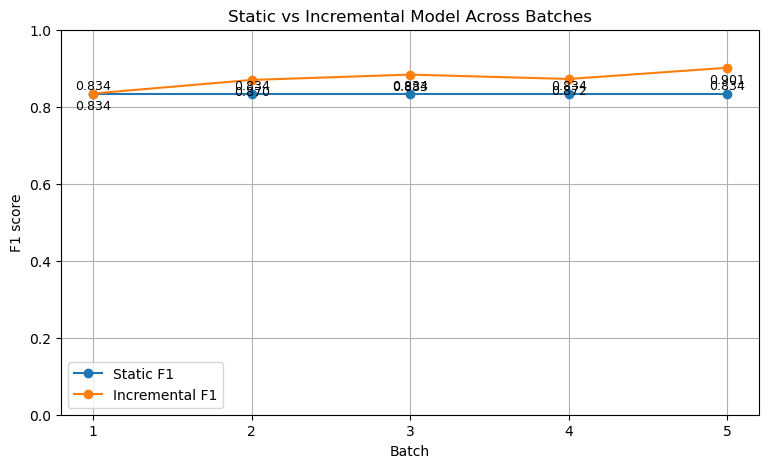

In [7]:
plt.figure(figsize=(9, 5))

plt.plot(history_df["batch"], history_df["static_f1"], marker="o", label="Static F1")
plt.plot(history_df["batch"], history_df["incremental_f1"], marker="o", label="Incremental F1")

for _, row in history_df.iterrows():
    plt.text(row["batch"], row["static_f1"] + 0.01, f'{row["static_f1"]:.3f}', ha="center", fontsize=9)
    plt.text(row["batch"], row["incremental_f1"] - 0.04, f'{row["incremental_f1"]:.3f}', ha="center", fontsize=9)

plt.xlabel("Batch")
plt.ylabel("F1 score")
plt.title("Static vs Incremental Model Across Batches")
plt.xticks(history_df["batch"])
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()

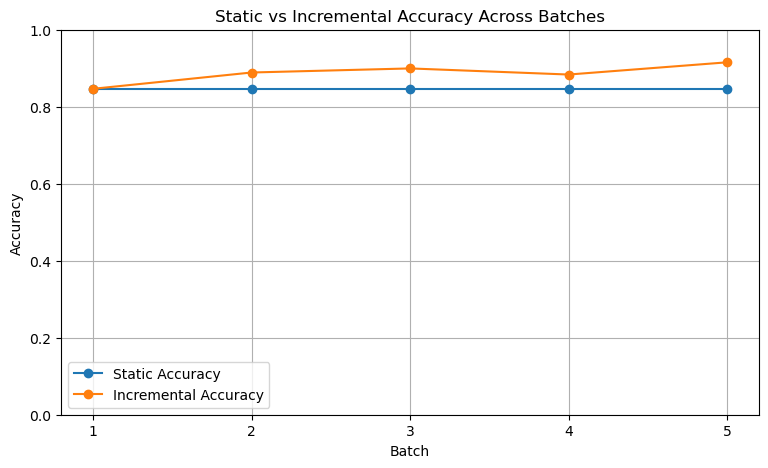

In [8]:
plt.figure(figsize=(9, 5))

plt.plot(history_df["batch"], history_df["static_accuracy"], marker="o", label="Static Accuracy")
plt.plot(history_df["batch"], history_df["incremental_accuracy"], marker="o", label="Incremental Accuracy")

plt.xlabel("Batch")
plt.ylabel("Accuracy")
plt.title("Static vs Incremental Accuracy Across Batches")
plt.xticks(history_df["batch"])
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()

In [9]:
comparison_df = history_df.copy()

comparison_df["accuracy_diff"] = comparison_df["incremental_accuracy"] - comparison_df["static_accuracy"]
comparison_df["precision_diff"] = comparison_df["incremental_precision"] - comparison_df["static_precision"]
comparison_df["recall_diff"] = comparison_df["incremental_recall"] - comparison_df["static_recall"]
comparison_df["f1_diff"] = comparison_df["incremental_f1"] - comparison_df["static_f1"]

comparison_df = comparison_df[
    [
        "batch",
        "static_accuracy", "incremental_accuracy", "accuracy_diff",
        "static_f1", "incremental_f1", "f1_diff",
        "static_precision", "incremental_precision", "precision_diff",
        "static_recall", "incremental_recall", "recall_diff"
    ]
]

comparison_df.round(4)

,batch,static_accuracy,incremental_accuracy,accuracy_diff,static_f1,incremental_f1,f1_diff,static_precision,incremental_precision,precision_diff,static_recall,incremental_recall,recall_diff
0,1,0.8466,0.8466,0.0000,0.8343,0.8343,0.0000,0.7604,0.7604,0.0000,0.9241,0.9241,0.0000
1,2,0.8466,0.8889,0.0423,0.8343,0.8696,0.0353,0.7604,0.8537,0.0932,0.9241,0.8861,-0.0380
2,3,0.8466,0.8995,0.0529,0.8343,0.8834,0.0491,0.7604,0.8571,0.0967,0.9241,0.9114,-0.0127
3,4,0.8466,0.8836,0.0370,0.8343,0.8721,0.0378,0.7604,0.8065,0.0460,0.9241,0.9494,0.0253
4,5,0.8466,0.9153,0.0688,0.8343,0.9012,0.0669,0.7604,0.8795,0.1191,0.9241,0.9241,0.0000


### Explanation:
Static model is being used as a base line to see whether incremental model is actually changing with additional data. The difference in performance for now is negligible, but the fact that it exists, demonstrates the incremental model changing as the new data arrives.
### Notes so far:
- Incremental learning model does not consistently get better with each batch. However it shows variance, which means model is changing. A major limitation is the absence of concept drift or other time-dependant structure that would create a scenario where incremental model could be prefered over static.
- Another main disadvantage- current dataset is fully synthetic, and not time dependant which means that any variance in the data that could be seen over prolonged time period will not be shown in this experiment.
- The main achievement at this stage is that the incremental model can be updated batch by batch and achieves different results from the frozen baseline as new data is introduced.

In [10]:
comparison_df = history_df.copy()

comparison_df["accuracy_diff"] = comparison_df["incremental_accuracy"] - comparison_df["static_accuracy"]
comparison_df["f1_diff"] = comparison_df["incremental_f1"] - comparison_df["static_f1"]

comparison_view = comparison_df[
    [
        "batch",
        "static_accuracy", "incremental_accuracy", "accuracy_diff",
        "static_f1", "incremental_f1", "f1_diff"
    ]
].round(4)

comparison_view

,batch,static_accuracy,incremental_accuracy,accuracy_diff,static_f1,incremental_f1,f1_diff
0,1,0.8466,0.8466,0.0000,0.8343,0.8343,0.0000
1,2,0.8466,0.8889,0.0423,0.8343,0.8696,0.0353
2,3,0.8466,0.8995,0.0529,0.8343,0.8834,0.0491
3,4,0.8466,0.8836,0.0370,0.8343,0.8721,0.0378
4,5,0.8466,0.9153,0.0688,0.8343,0.9012,0.0669


### Interpretation
Static model remains unchanged across all batches, since it is trained only once. It is used as a baseline for incremental model. Incremental model keeps changing with each batch, it confirms that additional data is being incorporated succesfully. However it does not mean that incremental model consistently improves with each batch. This setup demonstrates mechanics of incremental learning rather than advantages of it.
### Limitations
- Dataset is synthetic, thus it does not represent real time-dependant data.
- There is no concept drift in current batches.
- Experiment demonstrates incremental updating mechanics but advantages are not showcased.

